In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):	
	return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

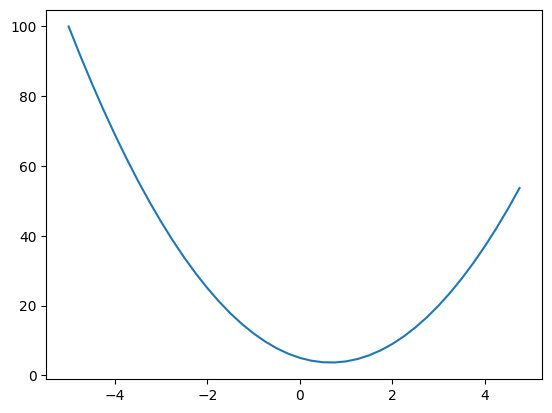

In [4]:
xs = np.arange (-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.000001
x = 2/3
(f(x+h)-f(x))/h

2.999378523327323e-06

In [6]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [8]:
from engine import Value

In [9]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

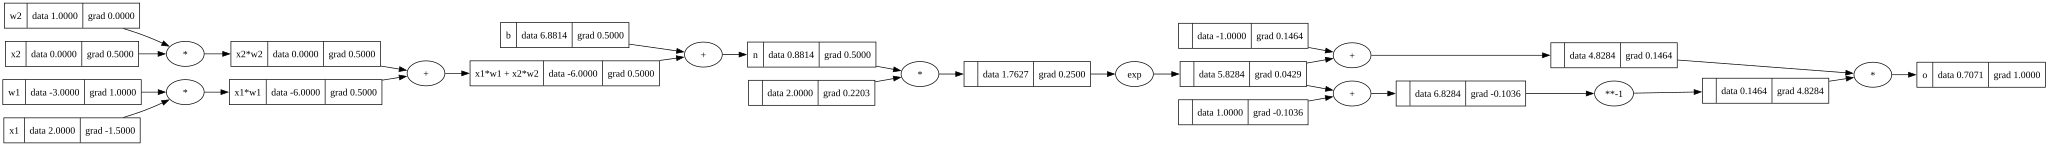

In [10]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

#o = n.tanh(); o.label = 'o'
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [11]:

from nn import Neuron, Layer, MLP
    
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
#draw_dot(n)
#draw_dot(n.layers[-1].neurons[-1])
n(x)

Value(data=0.29420868734660804, grad=0.0)

In [12]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.29420868734660804, grad=0.0),
 Value(data=0.9177257557504467, grad=0.0),
 Value(data=0.7700130439987503, grad=0.0),
 Value(data=0.6551204554317902, grad=0.0)]

41


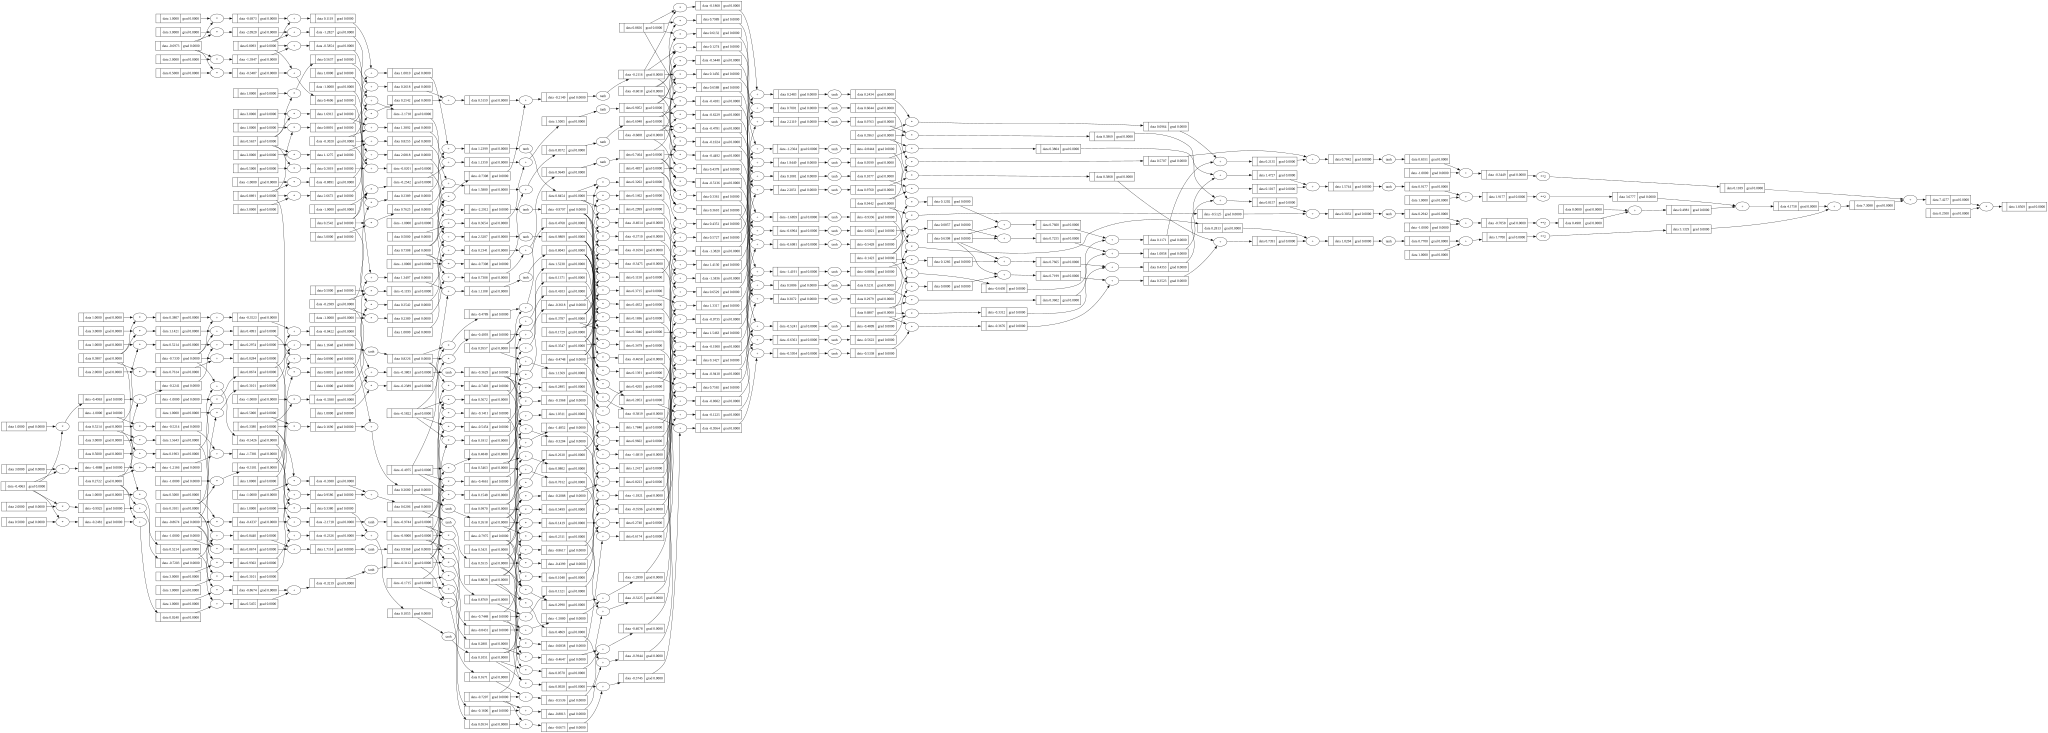

In [ ]:
loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) / len(ys)
print(len(n.parameters()))
#draw_dot(loss)

In [ ]:
for i in range(100):
    
    ypred = [n(x) for x in xs]
    loss = sum([(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]) / len(ys)
    print('loss', loss.data)

    n.zero_grad()
    loss.backward()

    alpha = 0.05
    for p in n.parameters():
        p.data += -alpha * p.grad
    
    print([y.data for y in ypred])

loss 1.8569253818682292
[0.29420868734660804, 0.9177257557504467, 0.7700130439987503, 0.6551204554317902]
loss 1.8209823033559476
[0.3092025602360205, 0.9031111728512136, 0.7520324191946686, 0.6604733051745758]
loss 1.7791043872327472
[0.3133357698922657, 0.8833263808639262, 0.72736721404471, 0.6620739207948819]
loss 1.7278197689513337
[0.3067752730893783, 0.8561615256800804, 0.6941021354291803, 0.6602929215863826]
loss 1.6631065200887785
[0.2890056004244265, 0.8185269330392867, 0.6495641947551378, 0.6553105668578687]
loss 1.5807823771075964
[0.259032388425753, 0.7664180948197479, 0.5904204500651694, 0.6472587161442308]
loss 1.4778202008415244
[0.21594831947603335, 0.6952999937381343, 0.5133874592699588, 0.636461700794067]
loss 1.354751068763229
[0.16018592218667851, 0.6012562682736469, 0.4171098429329628, 0.6238422589705972]
loss 1.2181456643127342
[0.09539296860512532, 0.4832184200632009, 0.30511306698946, 0.611397662435651]
loss 1.0804661229981278
[0.029596812783719447, 0.3459560400